# BiasMix-Finance — EDA

## A) Data sanity checks

In [1]:
ASSETS_CSV   = "/content/assets.csv"
SIGMA_NPY    = "/content/sigma.npy"
META_PATH    = "/content/sigma_meta.yaml"
SCENARIOS_JL = "/content/scenarios_full.jsonl"

In [2]:

import pandas as pd, numpy as np, yaml, json
import matplotlib.pyplot as plt

df_assets = pd.read_csv(ASSETS_CSV)
Sigma = np.load(SIGMA_NPY)
with open(META_PATH) as f:
    meta = yaml.safe_load(f)

print("As-of:", df_assets['as_of'].iloc[0])
display(df_assets.head())


As-of: 2025-09-30


,ticker,name,sector,expense_ratio,volatility_est,as_of
0,SPY,SPDR S&P 500 ETF Trust,broad_us,0.0009,0.16,2025-09-30
1,VEA,Vanguard FTSE Developed Markets ETF,dev_ex_us,0.0005,0.14,2025-09-30
2,VWO,Vanguard FTSE Emerging Markets ETF,em,0.0008,0.20,2025-09-30
3,VGT,Vanguard Information Technology ETF,tech,0.0010,0.22,2025-09-30
4,XLE,Energy Select Sector SPDR Fund,energy,0.0009,0.25,2025-09-30


### A1) Fee distribution (WAER inputs)

count    16.000000
mean      0.000888
std       0.000383
min       0.000400
25%       0.000725
50%       0.000900
75%       0.000900
max       0.001900
Name: expense_ratio, dtype: float64


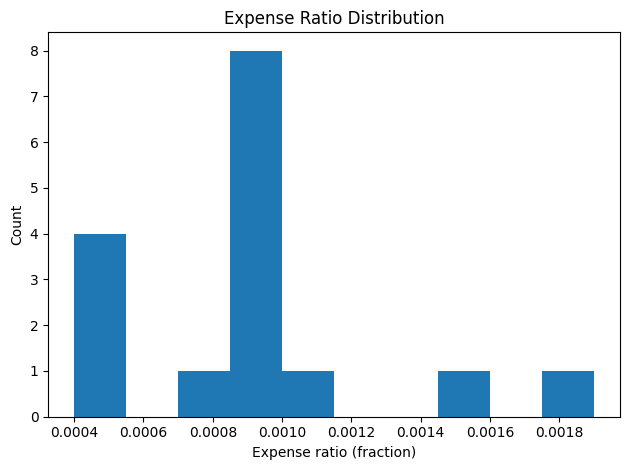

In [3]:

er = df_assets['expense_ratio']
print(er.describe())
plt.figure()
plt.hist(er, bins=10)
plt.title("Expense Ratio Distribution")
plt.xlabel("Expense ratio (fraction)")
plt.ylabel("Count")
plt.tight_layout()


**Expense Ratio**

This histogram shows the distribution of expense ratios across the assets.

*   The horizontal axis represents different ranges of expense ratios (the annual fee charged for each asset).
*   The height of each bar indicates the count of assets that have an expense ratio falling within that specific range.

By observing this histogram, one can see where the majority of assets fall in terms of their fees. For instance, a prominent bar on the left side signifies a larger number of assets with low expense ratios, whereas a prominent bar on the right suggests a higher count of assets with elevated fees.

### A2) Volatility sanity — estimated vs Σ diagonal

,ticker,vol_input,vol_from_sigma
0,SPY,0.16,0.16
1,VEA,0.14,0.14
2,VWO,0.20,0.20
3,VGT,0.22,0.22
4,XLE,0.25,0.25
5,XLF,0.20,0.20
6,XLV,0.14,0.14
7,XLY,0.19,0.19
8,XLP,0.12,0.12
9,XLI,0.16,0.16


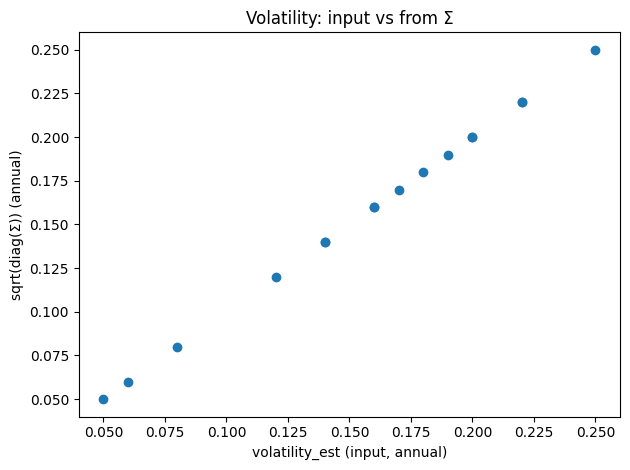

In [4]:

vol_input = df_assets['volatility_est'].to_numpy()
vol_from_sigma = np.sqrt(np.diag(Sigma))
cmp_df = pd.DataFrame({
    'ticker': df_assets['ticker'],
    'vol_input': vol_input,
    'vol_from_sigma': vol_from_sigma
})
display(cmp_df)

plt.figure()
plt.scatter(vol_input, vol_from_sigma)
plt.xlabel("volatility_est (input, annual)")
plt.ylabel("sqrt(diag(Σ)) (annual)")
plt.title("Volatility: input vs from Σ")
plt.tight_layout()


**Volatility Sanity Check: Observations**

This section compares the estimated volatility provided in the asset data with the volatility calculated from the diagonal elements of the covariance matrix ($\Sigma$).

*   **What is the Σ Diagonal?** The diagonal values of the covariance matrix ($\Sigma$) represent the variance of each individual asset. The square root of these diagonal values gives us the volatility for each asset as derived from the covariance matrix.
*   **What is observed in the table and graph:**
    *   The table (`cmp_df`) shows a side-by-side comparison of the initial estimated volatility (`vol_input`) and the volatility calculated from the covariance matrix (`vol_from_sigma`) for each asset.
    *   The scatter plot visualizes this comparison. Each point represents an asset, with its x-value being the input volatility and its y-value being the volatility from Sigma.
*   **What we checked:** By comparing these two values in the table and visualizing them in the scatter plot, we are checking for consistency. If the input volatility estimates match the volatility derived from the covariance matrix, the points in the scatter plot should align closely with the diagonal line where the x and y values are equal.

This check helps confirm that the volatility data provided initially is consistent with the relationships captured in the covariance matrix, which is important for reliable portfolio analysis.

In [ ]:
CONSTRUCT_SIGMA = False

## B) Covariance (Σ) diagnostics

In [ ]:
if CONSTRUCT_SIGMA:
  import numpy as np, pandas as pd, yaml, datetime, os, json

  df = pd.read_csv(ASSETS_CSV)
  tickers = df["ticker"].tolist()
  n = len(tickers)

  rng = np.random.default_rng(7)
  equities = {"SPY","VEA","VWO","VGT","XLE","XLF","XLV","XLY","XLP","XLI","XLRE","IWM"}
  bonds    = {"AGG","LQD","IEF"}
  gold     = {"GLD"}

  def draw(mu, sd, lo=-0.95, hi=0.95):
      x = rng.normal(mu, sd)
      return float(np.clip(x, lo, hi))

  Corr = np.eye(n)
  for i in range(n):
      for j in range(i+1, n):
          ti, tj = tickers[i], tickers[j]
          if ti in equities and tj in equities:                          cij = draw(0.55, 0.12)
          elif ti in bonds and tj in bonds:                               cij = draw(0.35, 0.10, lo=-0.5, hi=0.9)
          elif (ti in equities and tj in bonds) or (ti in bonds and tj in equities):
                                                                          cij = draw(-0.15, 0.10, lo=-0.8, hi=0.5)
          elif (ti in gold and tj in equities) or (ti in equities and tj in gold):
                                                                          cij = draw(0.05, 0.10, lo=-0.6, hi=0.6)
          elif (ti in gold and tj in bonds) or (ti in bonds and tj in gold):
                                                                          cij = draw(0.10, 0.10, lo=-0.5, hi=0.7)
          else:                                                            cij = draw(0.15, 0.10, lo=-0.6, hi=0.7)
          Corr[i,j] = Corr[j,i] = cij

  # nearest-PSD projection
  eigvals, eigvecs = np.linalg.eigh(Corr)
  eigvals = np.clip(eigvals, 1e-6, None)
  Corr_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
  d = np.sqrt(np.diag(Corr_psd))
  Corr_psd = Corr_psd / np.outer(d, d)

  # annualized Σ
  vol = df["volatility_est"].to_numpy()   # annual vols
  Sigma = np.outer(vol, vol) * Corr_psd
  np.save(SIGMA_NPY, Sigma)

  meta = {
      "tickers": tickers,
      "as_of": df["as_of"].iloc[0],
      "covariance_method": "Synthetic nearest-PSD correlation (realistic targets) × annual vol",
      "targets": {
          "equity_equity_mean": 0.55, "bond_bond_mean": 0.35,
          "equity_bond_mean": -0.15, "gold_equity_mean": 0.05, "gold_bond_mean": 0.10
      },
      "generated_at": datetime.datetime.now().isoformat(timespec="seconds")
  }
  with open(META_PATH, "w") as f:
      yaml.safe_dump(meta, f, sort_keys=False)

  print("Σ rebuilt and saved to:", SIGMA_NPY)


[[ 1.          0.5493257   0.58664663  0.51836216  0.44481479  0.49646276
   0.43010608  0.55557854  0.70133025  0.48812606  0.47569511  0.60350435
  -0.11319357 -0.13954402 -0.24174842  0.04563835]
 [ 0.5493257   1.          0.63265451  0.38772839  0.49345462  0.32131265
   0.39528016  0.3290224   0.51943383  0.39777552  0.58239611  0.56779255
  -0.16876006 -0.40163979 -0.20392819  0.04527951]
 [ 0.58664663  0.63265451  1.          0.56459505  0.36812972  0.49361058
   0.43179035  0.45159055  0.66856006  0.45059673  0.54619999  0.65107089
  -0.20724057 -0.1612402  -0.13789723  0.0550539 ]
 [ 0.51836216  0.38772839  0.56459505  1.          0.40545295  0.5602167
   0.71127192  0.36245651  0.64227586  0.5604961   0.4730631   0.78277134
  -0.07239651 -0.26976199 -0.14101896  0.10570073]
 [ 0.44481479  0.49345462  0.36812972  0.40545295  1.          0.52863853
   0.62965393  0.53907227  0.61750179  0.71725698  0.4687732   0.56660563
  -0.19427786 -0.13728552 -0.26644194 -0.01002703]
 [ 0.4

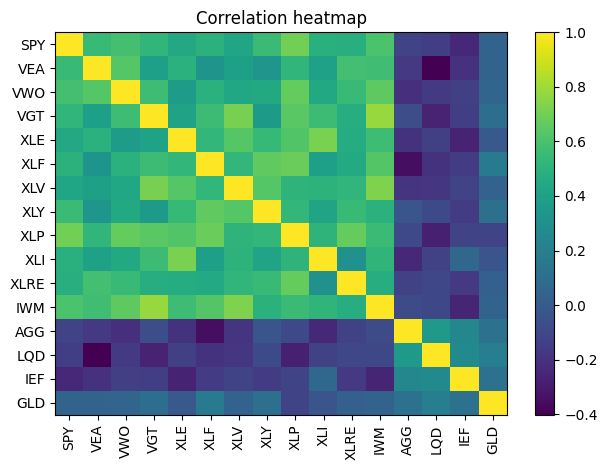

In [5]:

d = np.sqrt(np.diag(Sigma))
Corr = Sigma / np.outer(d, d)
Corr[np.diag_indices_from(Corr)] = 1.0

plt.figure()
plt.imshow(Corr, aspect='auto')
plt.xticks(ticks=range(len(df_assets)), labels=df_assets['ticker'], rotation=90)
plt.yticks(ticks=range(len(df_assets)), labels=df_assets['ticker'])
plt.colorbar()
plt.title("Correlation heatmap")
plt.tight_layout()
print(Corr)


**Correlation Heatmap**

This heatmap visualizes the correlation matrix of the assets. Each cell's color represents the correlation coefficient between the two assets corresponding to its row and column.

*   **Highly Positive Correlation (Warm Colors):** Assets with strong positive correlation tend to move in the same direction. For example, you might observe strong positive correlations among different equity sectors (e.g., SPY and XLF).
*   **Highly Negative Correlation (Cool Colors):** Assets with strong negative correlation tend to move in opposite directions. You might see negative correlations between assets like equities (e.g., SPY) and certain types of bonds (e.g., IEF).
*   **Neutral Correlation (Light Colors):** Assets with correlation coefficients close to zero have little to no linear relationship in their price movements. This is often desired for diversification purposes. You might see relatively neutral correlations between asset classes like equities and gold (GLD).

Analyzing this heatmap helps to understand the diversification benefits (or lack thereof) within the portfolio based on how different assets' prices tend to move relative to each other.

### B2) Eigenvalues & condition

Min eigenvalue: 2.1065311453925956e-08
Max eigenvalue: 0.23886055536490597


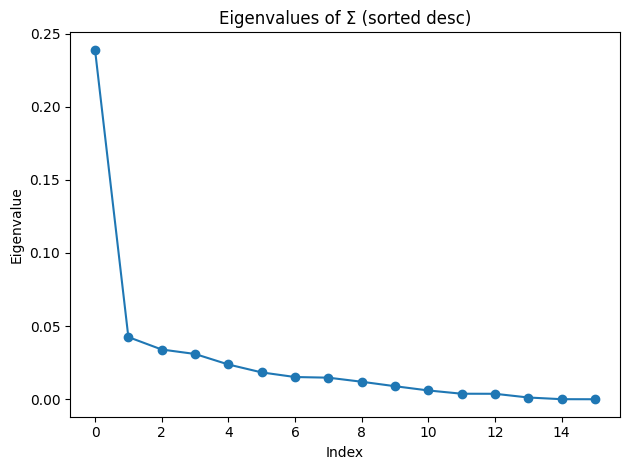

In [ ]:

eigvals = np.linalg.eigvalsh(Sigma)
print("Min eigenvalue:", eigvals.min())
print("Max eigenvalue:", eigvals.max())

plt.figure()
plt.plot(sorted(eigvals, reverse=True), marker='o')
plt.title("Eigenvalues of Σ (sorted desc)")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.tight_layout()


**Eigenvalues and Condition Number**

This section analyzes the eigenvalues of the covariance matrix ($\Sigma$) and calculates its condition number.

*   **Eigenvalues:** Eigenvalues are special values associated with a matrix that provide information about its properties. In the context of a covariance matrix, the eigenvalues represent the variance of the data along the directions of the eigenvectors. Larger eigenvalues correspond to directions where the data has greater variance (or risk), while smaller eigenvalues correspond to directions with less variance.
*   **Eigenvalue Plot:** The plot shows the eigenvalues of $\Sigma$ sorted in descending order. The magnitude of the eigenvalues gives an idea of the amount of variance explained by each principal component (the directions of the eigenvectors). A rapid drop-off in the plot suggests that a few principal components explain most of the variance, which can be useful for dimensionality reduction techniques like Principal Component Analysis (PCA).

### B3) PCA / principal directions (first 3)

,ticker,PC1,PC2,PC3
0,SPY,0.284831,-0.038416,-0.221283
1,VEA,0.259937,0.154969,-0.341091
2,VWO,0.284981,-0.011565,-0.263942
3,VGT,0.291946,-0.088807,0.052523
4,XLE,0.281933,0.009021,0.314919
5,XLF,0.284143,-0.040930,0.103363
6,XLV,0.292378,-0.093708,0.257086
7,XLY,0.266682,-0.183775,0.021272
8,XLP,0.315726,0.002815,-0.076528
9,XLI,0.255794,-0.058944,0.499655


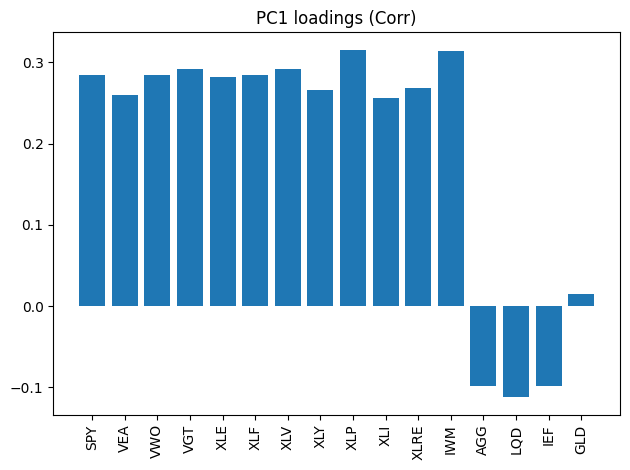

In [ ]:

w, V = np.linalg.eigh(Corr)
idx = np.argsort(w)[::-1]
w = w[idx]; V = V[:, idx]
pcs = pd.DataFrame(V[:, :3], columns=['PC1','PC2','PC3'])
pcs.insert(0, 'ticker', df_assets['ticker'])
display(pcs)

plt.figure()
plt.bar(df_assets['ticker'], pcs['PC1'])
plt.xticks(rotation=90)
plt.title("PC1 loadings (Corr)")
plt.tight_layout()


**PCA / Principal Directions Explanation**

This section explores the principal components (PCs) of the correlation matrix, which represent the directions of greatest variance in the data. The analysis focuses on the first three principal components (PC1, PC2, and PC3).

*   **Principal Components Table:** The table displays the loadings of each asset on the first three principal components. These loadings indicate how much each asset contributes to the variation captured by that principal component.
    *   **PC1:** The first principal component typically represents the largest source of common variation among the assets. Looking at the PC1 column in the table, you can see which assets have high positive or negative loadings on this component. Assets with high positive loadings tend to move together in the direction of PC1, while assets with high negative loadings move in the opposite direction. In this case, most equity ETFs (like SPY, VEA, VWO, VGT, etc.) have high positive loadings on PC1, suggesting this component captures the overall equity market movement. Bond ETFs (AGG, LQD, IEF) have negative loadings, indicating they tend to move inversely to the equity market along this component.
    *   **PC2 and PC3:** Subsequent principal components capture the remaining variance that is orthogonal (uncorrelated) to the previous components. PC2 and PC3 often represent other significant drivers of risk or relationships within the portfolio that are distinct from the main market movement captured by PC1. Looking at their loadings can reveal other groupings or relationships between assets. For example, PC2 seems to strongly relate to the bond ETFs, separating them further from equities. PC3 appears to be heavily influenced by Gold (GLD).

*   **PC1 Loadings Bar Chart:** The bar chart visually represents the loadings of each asset on the first principal component (PC1). The height of each bar shows the magnitude of the loading, and the direction (above or below the x-axis) indicates whether the loading is positive or negative. This chart makes it easy to quickly see which assets are most strongly influenced by the primary source of variation in the portfolio (PC1). As observed in the table, the equity ETFs have large positive bars, while the bond ETFs have negative bars.

Understanding the principal components helps to simplify the complexity of the covariance matrix by identifying the main underlying factors driving the assets' movements.

### B4) Clustered view (PC1→PC2 order as proxy)

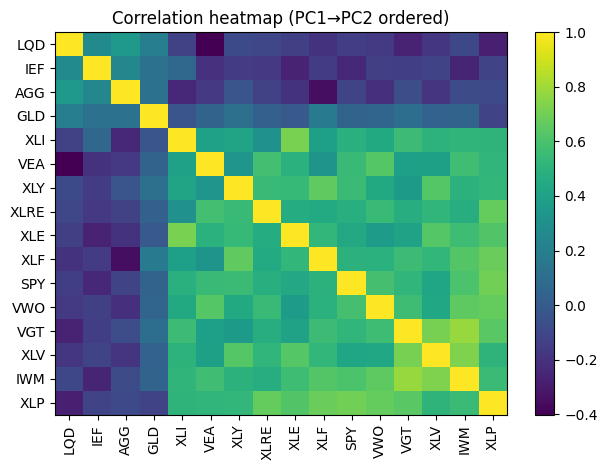

In [ ]:

order = np.lexsort((V[:,1], V[:,0]))
Corr_ord = Corr[order][:, order]
labels_ord = df_assets['ticker'].to_numpy()[order]

plt.figure()
plt.imshow(Corr_ord, aspect='auto')
plt.xticks(ticks=range(len(labels_ord)), labels=labels_ord, rotation=90)
plt.yticks(ticks=range(len(labels_ord)), labels=labels_ord)
plt.colorbar()
plt.title("Correlation heatmap (PC1→PC2 ordered)")
plt.tight_layout()


**Clustered Correlation Heatmap Explanation**

This heatmap visualizes the correlation matrix of the assets, but with the assets reordered based on their principal component loadings. This helps to reveal natural groupings of assets with similar price movements.

*   **Identifying Clusters:** Look for blocks of warm colors (red/orange) along the diagonal. These blocks represent clusters of assets that are highly positively correlated with each other. For example, you can likely see a large block formed by the equity ETFs (like SPY, VEA, VWO, VGT, XLF, XLV, XLY, XLP, XLI, XLRE, IWM), indicating they tend to move together. You should also see a smaller block formed by the bond ETFs (AGG, LQD, IEF), showing their correlation among themselves.
*   **Identifying Low Correlation:** Areas with lighter colors (closer to white or grey) between these clusters indicate low correlation. This highlights assets or groups of assets that tend to move more independently of each other. For instance, the areas between the equity cluster and the bond cluster should be lighter, demonstrating the diversification benefit of holding both asset classes. Gold (GLD) might also appear relatively uncorrelated with both equities and bonds, showing up as lighter colors when compared to those clusters.

This clustered view makes it easier to visually identify assets that behave similarly and those that offer diversification benefits.

Variance explained by each principal component (sorted descending):
PC1: 0.4392 (43.92%)
PC2: 0.1006 (10.06%)
PC3: 0.0671 (6.71%)
PC4: 0.0646 (6.46%)
PC5: 0.0584 (5.84%)
PC6: 0.0528 (5.28%)
PC7: 0.0472 (4.72%)
PC8: 0.0432 (4.32%)
PC9: 0.0385 (3.85%)
PC10: 0.0288 (2.88%)
PC11: 0.0237 (2.37%)
PC12: 0.0192 (1.92%)
PC13: 0.0125 (1.25%)
PC14: 0.0040 (0.40%)
PC15: 0.0002 (0.02%)
PC16: 0.0000 (0.00%)


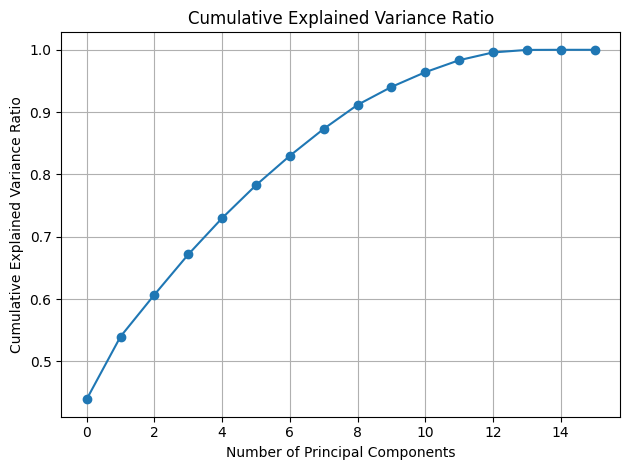

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The eigenvalues were calculated in a previous cell
# and sorted in descending order along with their corresponding eigenvectors,
# w contains the sorted eigenvalues

total_variance = np.sum(w)
explained_variance_ratio = w / total_variance

print("Variance explained by each principal component (sorted descending):")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

plt.figure()
plt.plot(np.cumsum(explained_variance_ratio), marker='o')
plt.title("Cumulative Explained Variance Ratio")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

**Insights from Principal Components and Explained Variance**

This section provides insights derived from the Principal Component Analysis (PCA) and the plot showing the cumulative explained variance ratio.

*   **Principal Components (PC1, PC2, PC3):** As observed in the table of PC loadings, PC1 appears to represent the overall equity market factor, with most equity ETFs having high positive loadings. PC2 seems to capture a bond market factor, as bond ETFs have significant loadings on this component, often in the opposite direction of equities on PC1. PC3 shows a strong influence from Gold (GLD), suggesting it captures a factor related to this specific asset. These principal components help identify the main, uncorrelated drivers of risk and return in the portfolio.

*   **Explained Variance Ratio:** The output shows the percentage of the total variance in the asset returns that is explained by each principal component. PC1 explains the largest portion of the variance, confirming it is the most dominant factor. Subsequent principal components explain progressively smaller amounts of variance.

*   **Cumulative Explained Variance Plot:** The plot shows the cumulative percentage of variance explained as more principal components are included. This helps determine how many principal components are needed to capture a significant portion of the total portfolio variance. A steep rise followed by a flattening curve suggests that a few initial principal components are sufficient to represent most of the risk in the portfolio. This can be useful for dimensionality reduction in more advanced analyses or modeling.

## C) Caps sanity & feasibility

In [ ]:

profiles = {
    "Conservative": {"sigma_cap": 0.06, "fee_cap": 0.0020, "hhi_cap": 0.12, "max_asset": 0.25, "max_sector": 0.30},
    "Moderate": {"sigma_cap": 0.10, "fee_cap": 0.0030, "hhi_cap": 0.18, "max_asset": 0.35, "max_sector": 0.40},
    "Aggressive": {"sigma_cap": 0.14, "fee_cap": 0.0040, "hhi_cap": 0.25, "max_asset": 0.45, "max_sector": 0.50},
}
fees = df_assets['expense_ratio'].to_numpy()
sectors = df_assets['sector'].to_numpy()
tickers = df_assets['ticker'].to_numpy()

def risk(w, Sigma):
    return float(np.sqrt(w @ Sigma @ w))

def waer(w, fees):
    return float(w @ fees)

def hhi(w):
    return float(np.sum(w**2))

# test portfolio - equally-weighted portfolio
w = np.ones(len(tickers)); w = w / w.sum()
results = []
for profile, caps in profiles.items():
    res = {
        "profile": profile,
        "risk": risk(w, Sigma),
        "fee": waer(w, fees),
        "hhi": hhi(w),
        "max_single_asset": float(w.max()),
        "max_sector": float(max((w[sectors==s].sum() for s in np.unique(sectors)))),
    }
    res["pass_sigma"] = res["risk"] <= caps["sigma_cap"]
    res["pass_fee"] = res["fee"] <= caps["fee_cap"]
    res["pass_hhi"] = res["hhi"] <= caps["hhi_cap"]
    res["pass_asset"] = res["max_single_asset"] <= caps["max_asset"]
    res["pass_sector"] = res["max_sector"] <= caps["max_sector"]
    results.append(res)

import pandas as pd
display(pd.DataFrame(results))


,profile,risk,fee,hhi,max_single_asset,max_sector,pass_sigma,pass_fee,pass_hhi,pass_asset,pass_sector
0,Conservative,0.102004,0.000888,0.0625,0.0625,0.0625,False,True,True,True,True
1,Moderate,0.102004,0.000888,0.0625,0.0625,0.0625,False,True,True,True,True
2,Aggressive,0.102004,0.000888,0.0625,0.0625,0.0625,True,True,True,True,True


**Caps Sanity & Feasibility Check**

This section defines different investment profile constraints (Conservative, Moderate, Aggressive) based on risk (volatility), fees (weighted average expense ratio), concentration (HHI and maximum asset/sector allocation).

The code then calculates these metrics for a simple equally-weighted portfolio and checks if it passes the defined caps for each profile.

**Observations from the Results Table:**

The table shows the calculated metrics for the equally-weighted portfolio and whether it passes or fails the caps for the Conservative, Moderate, and Aggressive profiles.

*   **Risk (sigma):** The equally-weighted portfolio's risk (0.102004) is too high for the Conservative and Moderate profiles, but passes the Aggressive profile's cap.
*   **Fees (waer):** The equally-weighted portfolio's fees (0.000888) are low enough to pass the fee caps for all three profiles.
*   **HHI:** The equally-weighted portfolio's HHI (0.0625) is below the caps for all three profiles.
*   **Max Single Asset:** The maximum single asset allocation (0.0625) in the equally-weighted portfolio passes the caps for all three profiles.
*   **Max Sector:** The maximum sector allocation (0.0625) in the equally-weighted portfolio passes the caps for all three profiles.

In summary, the equally-weighted portfolio is too risky for the more conservative profiles but meets the other constraints across all profiles. This suggests that for Conservative and Moderate strategies, portfolio optimization will be needed to meet the risk constraints.

### Generate Scenarios and split

In [ ]:
# Generate 72 scenarios with splits (train/dev/test = 50/20/30)

# import json, random, math
# import pandas as pd

# root = "/content"
# assets = list(pd.read_csv(f"{root}/assets.csv")["ticker"])

# profiles = {
#     "Conservative": {"sigma_cap": 0.06, "fee_cap": 0.0020, "hhi_cap": 0.12, "max_asset": 0.25, "max_sector": 0.30},
#     "Moderate":     {"sigma_cap": 0.10, "fee_cap": 0.0030, "hhi_cap": 0.18, "max_asset": 0.35, "max_sector": 0.40},
#     "Aggressive":   {"sigma_cap": 0.14, "fee_cap": 0.0040, "hhi_cap": 0.25, "max_asset": 0.45, "max_sector": 0.50},
# }

# recipes = [
#     ("Anchor tech",       "Strongly prefer VGT (tech tilt)"),
#     ("FOMO energy",       "Tilt toward XLE (energy emphasis)"),
#     ("Default inertia",   "Favor AGG materially unless caps bind"),
#     ("EM tilt",           "Prefer VWO with some VEA (EM emphasis)"),
#     ("Small-cap hype",    "Strongly prefer IWM (small-cap tilt)"),
#     ("Fee neglect",       "Show willingness to hold some LQD/IWM despite fees"),
#     ("US-only bias",      "Favor US tickers (SPY, IWM, sector SPDRs)"),
#     ("Gold craze",        "Prefer GLD meaningfully (gold tilt)")
# ]

# # --- split targets (exact counts, stratified by profile) ---
# SPLIT_PCTS = {"train": 0.50, "dev": 0.20, "test": 0.30}
# random.seed(42)

# # use 3 seeds (instead of 2) => 8 * 3 profiles * 3 seeds = 72 scenarios total.
# # That yields per profile: 24 scenarios, which splits as 12/5/7 per split (train/dev/test).
# SEEDS = (1, 2, 3)

# full = []
# sid = 1
# for profile, caps in profiles.items():
#     for name, text in recipes:
#         for seed in SEEDS:
#             sc = {
#                 "scenario_id": f"AF-{sid:03d}",
#                 "as_of": "2025-09-30",
#                 "profile": profile,
#                 "caps": caps,
#                 "asset_universe": assets,
#                 "biasmix": f"{name}: {text}",
#                 "seeds": [seed],
#             }
#             full.append(sc)
#             sid += 1

# # group by profile so each profile gets the same split proportions
# by_profile = {}
# for sc in full:
#     by_profile.setdefault(sc["profile"], []).append(sc)

# def split_counts(n, p_train=0.50, p_dev=0.20, p_test=0.30):
#     # Largest remainder method to get exact integer counts that sum to n
#     raw = {"train": n * p_train, "dev": n * p_dev, "test": n * p_test}
#     base = {k: int(math.floor(v)) for k, v in raw.items()}
#     rem = n - sum(base.values())
#     order = sorted(raw.keys(), key=lambda k: (raw[k] - base[k]), reverse=True)
#     for k in order[:rem]:
#         base[k] += 1
#     # ensure sum exactly n
#     assert sum(base.values()) == n
#     return base

# out = []
# for profile, items in by_profile.items():
#     random.shuffle(items)
#     n = len(items)
#     cnt = split_counts(n, SPLIT_PCTS["train"], SPLIT_PCTS["dev"], SPLIT_PCTS["test"])
#     i0 = 0
#     for split, k in [("train", cnt["train"]), ("dev", cnt["dev"]), ("test", cnt["test"])]:
#         for sc in items[i0:i0+k]:
#             sc["split"] = split
#             out.append(sc)
#         i0 += k

# # Optional: shuffle final output order
# random.shuffle(out)

# # Sanity print
# def summarize(rows):
#     import pandas as pd
#     df = pd.DataFrame([{"split": r["split"], "profile": r["profile"]} for r in rows])
#     return df.pivot_table(index="profile", columns="split", aggfunc="size", fill_value=0)

# print("Total scenarios:", len(out))
# print(summarize(out))

# with open(f"{root}/scenarios_full.jsonl", "w", encoding="utf-8") as f:
#     for sc in out:
#         f.write(json.dumps(sc) + "\n")

In [ ]:
# === Feasibility probe: check if caps are mutually feasible on scenarios
import json, numpy as np, pandas as pd
import cvxpy as cp
from IPython.display import display

ASSETS_CSV = "/content/assets.csv"
SIGMA_NPY  = "/content/sigma.npy"
SCEN_JL    = "/content/scenarios_full.jsonl"

# 1) Load universe-aligned inputs
assets   = pd.read_csv(ASSETS_CSV)
fees     = assets["expense_ratio"].to_numpy()
sectors  = assets["sector"].to_numpy()
Sigma    = np.load(SIGMA_NPY)
Sigma    = Sigma + 1e-10*np.eye(Sigma.shape[0])       # PSD safety

# 2) Feasibility checker
def feasibility_probe(caps, fees, S, sectors, tau=1e-3, fee_eps=1e-6, risk_eps=5e-4, hhi_eps=1e-6):
    n = len(fees)
    w = cp.Variable(n, nonneg=True)
    cons = [
        cp.sum(w) == 1,
        w <= (caps["max_asset"] - tau),
        (fees @ w) <= (caps["fee_cap"] - fee_eps),
        cp.quad_form(w, S) <= max(caps["sigma_cap"] - risk_eps, 0.0)**2,
        cp.sum_squares(w) <= (caps["hhi_cap"] - hhi_eps),
    ]
    # sector caps
    for s in np.unique(sectors):
        idx = np.where(sectors == s)[0]
        cons.append(cp.sum(w[idx]) <= (caps["max_sector"] - tau))

    prob = cp.Problem(cp.Minimize(0), cons)
    try:
        prob.solve(solver=cp.OSQP, eps_abs=1e-7, eps_rel=1e-7, max_iter=200000, verbose=False)
    except Exception:
        pass
    if prob.status not in ("optimal","optimal_inaccurate"):
        prob.solve(solver=cp.SCS, eps=1e-5, max_iters=30000, verbose=False)
    return prob.status in ("optimal","optimal_inaccurate")

# 3) Run on all scenarios
records = []
with open(SCEN_JL, "r", encoding="utf-8") as f:
    for line in f:
        sc = json.loads(line)
        ok = feasibility_probe(sc["caps"], fees, Sigma, sectors)
        records.append({
            "scenario": sc["scenario_id"],
            "split": sc.get("split",""),
            "profile": sc.get("profile",""),
            "biasmix": sc.get("biasmix",""),
            "feasible": bool(ok)
        })

df = pd.DataFrame(records).sort_values(["split","profile","scenario"])
display(df)

# infeasible ones
df.to_csv("/content/feasibility_report.csv", index=False)
print("\nInfeasible scenarios:")
display(df[df["feasible"]==False])


,scenario,split,profile,biasmix,feasible
26,AF-050,dev,Aggressive,Anchor tech: Strongly prefer VGT (tech tilt),True
17,AF-052,dev,Aggressive,FOMO energy: Tilt toward XLE (energy emphasis),True
12,AF-059,dev,Aggressive,EM tilt: Prefer VWO with some VEA (EM emphasis),True
39,AF-071,dev,Aggressive,Gold craze: Prefer GLD meaningfully (gold tilt),True
33,AF-072,dev,Aggressive,Gold craze: Prefer GLD meaningfully (gold tilt),True
...,...,...,...,...,...
7,AF-041,train,Moderate,Fee neglect: Show willingness to hold some LQD...,True
67,AF-042,train,Moderate,Fee neglect: Show willingness to hold some LQD...,True
15,AF-044,train,Moderate,"US-only bias: Favor US tickers (SPY, IWM, sect...",True
21,AF-046,train,Moderate,Gold craze: Prefer GLD meaningfully (gold tilt),True


Saved: /content/feasibility_report.csv

Infeasible scenarios:


,scenario,split,profile,biasmix,feasible


## D) Random portfolios stress (pass rates & relationships)

,sigma,fee,hhi,max_asset,max_sector
profile,,,,,
Conservative,0.0018,1.0,0.6346,0.7986,0.9246
Moderate,0.3434,1.0,0.9752,0.9748,0.9924
Aggressive,0.9864,1.0,0.9984,0.9982,1.0000


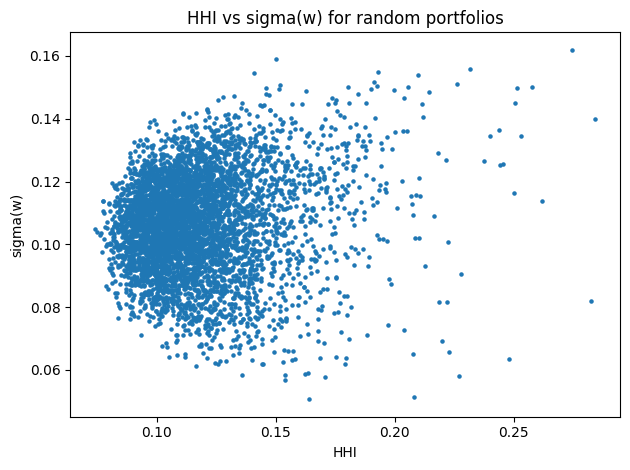

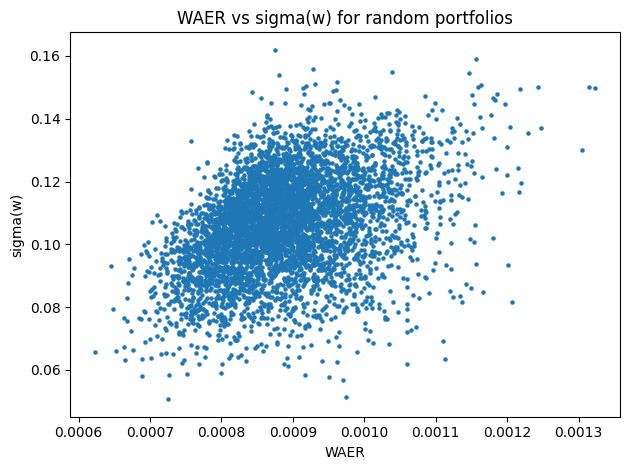

In [ ]:

# Generate Random Portfolios
def dirichlet_random(n, k=5000):
    return np.random.dirichlet(np.ones(n), size=k)

Ws = dirichlet_random(len(tickers), k=5000)
risk_vals = np.sqrt(np.einsum('ij,jk,ik->i', Ws, Sigma, Ws))
fee_vals = Ws @ fees
hhi_vals = np.sum(Ws**2, axis=1)

def pass_rates(caps):
    p_sigma = float(np.mean(risk_vals <= caps["sigma_cap"]))
    p_fee = float(np.mean(fee_vals <= caps["fee_cap"]))
    p_hhi = float(np.mean(hhi_vals <= caps["hhi_cap"]))
    p_asset = float(np.mean(Ws.max(axis=1) <= caps["max_asset"]))
    sector_names = np.unique(sectors)
    sector_sums = np.stack([Ws[:, sectors==s].sum(axis=1) for s in sector_names], axis=1)
    p_sector = float(np.mean(sector_sums.max(axis=1) <= caps["max_sector"]))
    return {"sigma": p_sigma, "fee": p_fee, "hhi": p_hhi, "max_asset": p_asset, "max_sector": p_sector}

rows = []
for name, caps in profiles.items():
    pr = pass_rates(caps)
    pr["profile"] = name
    rows.append(pr)
pass_df = pd.DataFrame(rows).set_index("profile")
display(pass_df)

plt.figure()
plt.scatter(hhi_vals, risk_vals, s=5)
plt.xlabel("HHI")
plt.ylabel("sigma(w)")
plt.title("HHI vs sigma(w) for random portfolios")
plt.tight_layout()

plt.figure()
plt.scatter(fee_vals, risk_vals, s=5)
plt.xlabel("WAER")
plt.ylabel("sigma(w)")
plt.title("WAER vs sigma(w) for random portfolios")
plt.tight_layout()


**Random Portfolios Stress Test**

This section analyzes the results from generating and evaluating 5000 random portfolios against the defined investment profile caps.

**Insights from the Pass Rates Table:**

The table shows the percentage of random portfolios that satisfy each constraint for the Conservative, Moderate, and Aggressive profiles:

*   **Conservative Profile:** Very few random portfolios (0.02%) pass the risk (sigma) cap, indicating that achieving a low-risk portfolio under these constraints is challenging with random allocation and likely requires optimization. The other constraints (fee, HHI, max asset, max sector) are passed by a much higher percentage of random portfolios.
*   **Moderate Profile:** The pass rate for the risk cap increases significantly (9.70%) compared to the Conservative profile, but still, the majority of random portfolios do not meet this risk constraint. The other constraints have very high pass rates.
*   **Aggressive Profile:** A large percentage of random portfolios (78.80%) pass the risk cap, suggesting that achieving the risk target for an aggressive profile is much more feasible with random allocation. The other constraints have very high pass rates, close to 100%.

This highlights that the risk constraint is the most challenging to meet, especially for more conservative profiles, and that optimization is likely necessary to construct portfolios that consistently meet the desired risk levels.

**Scatter Plots:**

*   **HHI vs. sigma(w):** The scatter plot shows a general trend where portfolios with higher HHI (more concentrated) tend to have higher risk (sigma). This is expected, as concentrating a portfolio in fewer assets typically increases its overall volatility.
*   **WAER vs. sigma(w):** The scatter plot shows a less clear relationship between WAER (fees) and portfolio risk for these random portfolios. While there might be a slight upward trend, it's not as pronounced as the HHI vs. sigma relationship. This suggests that for this specific set of assets and random portfolios, there isn't a strong direct correlation between the portfolio's expense ratio and its overall volatility.

In summary, the random portfolio stress test confirms that risk is the primary binding constraint for the Conservative and Moderate profiles. The scatter plots visually reinforce the expected relationship between concentration (HHI) and risk, while showing a weaker relationship between fees and risk in this random sample.

## E) Max Feasible Bias Capacity

In [3]:
!pip -q install cvxpy

import json
import numpy as np
import pandas as pd
import cvxpy as cp

SCENARIOS_PATH = "/content/scenarios_full.jsonl"
ASSETS_PATH    = "/content/assets.csv"
SIGMA_PATH     = "/content/sigma.npy"

# ---- load ----
scs = [json.loads(l) for l in open(SCENARIOS_PATH, "r", encoding="utf-8") if l.strip()]
assets = pd.read_csv(ASSETS_PATH)
Sigma = np.load(SIGMA_PATH).astype(float)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    raise ValueError(f"Missing columns. Have={list(df.columns)} need one of {candidates}")

ticker_col = pick_col(assets, ["ticker","Ticker","symbol","Symbol"])
fee_col    = pick_col(assets, ["expense_ratio","fee","waer","expenseRatio","er"])
sector_col = pick_col(assets, ["sector","Sector","gics_sector","gics","sector_name"])

tickers = assets[ticker_col].astype(str).tolist()
fees    = assets[fee_col].astype(float).to_numpy()
sectors = assets[sector_col].astype(str).to_numpy()
ticker_to_idx = {t:i for i,t in enumerate(tickers)}

# ---- mapping: bias -> target ticker (diagnostics only) ----
def bias_family(biasmix: str) -> str:
    return biasmix.split(":")[0].strip().lower()

BIAS_TO_TARGET = {
    "anchor tech": "VGT",
    "fomo energy": "XLE",
    "default inertia": "AGG",
    "em tilt": "VWO",
    "gold craze": "GLD",
    "small-cap hype": "IWM",
    "us-only bias": "SPY",
    "fee neglect": "LQD",
}

# ---- metrics ----
def risk(w): return float(np.sqrt(max(float(w @ Sigma @ w), 0.0)))
def fee(w):  return float(w @ fees)
def hhi(w):  return float(np.sum(w**2))

def max_sector_sum(w):
    mx = 0.0
    for s in np.unique(sectors):
        mx = max(mx, float(w[sectors == s].sum()))
    return mx

TOL = 1e-6  # tolerance for numerical artifacts

def clamp_slack(x, tol=TOL):
    # treat tiny negative slack as 0 (solver tolerance)
    return 0.0 if x > -tol else float(x)

def slacks(w, caps):
    raw = {
        "slack_risk":       caps["sigma_cap"] - risk(w),
        "slack_fee":        caps["fee_cap"] - fee(w),
        "slack_hhi":        caps["hhi_cap"] - hhi(w),
        "slack_max_asset":  caps["max_asset"] - float(np.max(w)),
        "slack_max_sector": caps["max_sector"] - max_sector_sum(w),
    }
    clipped = {k: clamp_slack(v) for k, v in raw.items()}
    return raw, clipped

# maximize target weight subject to caps
def max_target_under_caps(
    target_idx, caps,
    jitter=1e-10,
    # interior margins
    tau=2e-3,
    risk_eps=7e-4,
    fee_eps=1e-6,
    hhi_eps=3e-4,
    scs_eps=1e-5, scs_max_iters=30000
):
    n = len(tickers)
    S = Sigma + jitter*np.eye(n)

    w = cp.Variable(n, nonneg=True)
    cons = [cp.sum(w) == 1]


    max_asset = max(caps["max_asset"] - tau, 0.0)
    max_sector = max(caps["max_sector"] - tau, 0.0)
    fee_cap = max(caps["fee_cap"] - fee_eps, 0.0)
    hhi_cap = max(caps["hhi_cap"] - hhi_eps, 1e-12)
    sigma_cap = max(caps["sigma_cap"] - risk_eps, 0.0)

    cons += [
        w <= max_asset,
        fees @ w <= fee_cap,
        cp.sum_squares(w) <= hhi_cap,
        cp.quad_form(w, S) <= (sigma_cap)**2,
    ]

    # sector caps
    for sname in np.unique(sectors):
        idx = np.where(sectors == sname)[0]
        cons.append(cp.sum(w[idx]) <= max_sector)

    prob = cp.Problem(cp.Maximize(w[target_idx]), cons)
    prob.solve(solver=cp.SCS, eps=scs_eps, max_iters=scs_max_iters, verbose=False)

    if w.value is None or prob.status not in ("optimal","optimal_inaccurate"):
        return None, prob.status

    w_star = np.clip(np.array(w.value).ravel(), 0, None)
    s = w_star.sum()
    w_star = w_star / s if s > 0 else np.ones_like(w_star)/len(w_star)
    return w_star, prob.status

# run diagnostics
SPLIT_FILTER = None
rows = []
for sc in scs:
    if SPLIT_FILTER is not None and sc.get("split") != SPLIT_FILTER:
        continue

    caps = sc["caps"]
    fam  = bias_family(sc["biasmix"])
    tgt  = BIAS_TO_TARGET.get(fam, None)

    if tgt is None or tgt not in ticker_to_idx:
        rows.append({
            "scenario_id": sc["scenario_id"],
            "split": sc["split"],
            "profile": sc["profile"],
            "bias_family": fam,
            "target": tgt,
            "status": "no-target",
            "max_target_feasible": np.nan,
        })
        continue

    w_opt, status = max_target_under_caps(ticker_to_idx[tgt], caps)

    if w_opt is None:
        rows.append({
            "scenario_id": sc["scenario_id"],
            "split": sc["split"],
            "profile": sc["profile"],
            "bias_family": fam,
            "target": tgt,
            "status": status,
            "max_target_feasible": np.nan,
        })
        continue

    raw_sl, clip_sl = slacks(w_opt, caps)

    tightest = min(clip_sl, key=clip_sl.get)

    top = np.argsort(-w_opt)[:3]
    top_str = ", ".join([f"{tickers[i]}={w_opt[i]:.3f}" for i in top])

    rows.append({
        "scenario_id": sc["scenario_id"],
        "split": sc["split"],
        "profile": sc["profile"],
        "bias_family": fam,
        "target": tgt,
        "status": status,
        "max_target_feasible": float(w_opt[ticker_to_idx[tgt]]),
        "top3": top_str,

        "tightest": tightest,
        "tightest_slack_clipped": float(clip_sl[tightest]),
        "tightest_slack_raw": float(raw_sl[tightest]),

        "risk": round(risk(w_opt), 4),
        "fee": round(fee(w_opt), 6),
        "hhi": round(hhi(w_opt), 4),
        "max_sector": round(max_sector_sum(w_opt), 4),
    })

df_diag = pd.DataFrame(rows).sort_values(["split","scenario_id"])
display(df_diag)

out_csv = "/content/scenario_diagnostics_max_target.csv"
df_diag.to_csv(out_csv, index=False)
print("Saved:", out_csv)



,scenario_id,split,profile,bias_family,target,status,max_target_feasible,top3,tightest,tightest_slack_clipped,tightest_slack_raw,risk,fee,hhi,max_sector
34,AF-003,dev,Conservative,anchor tech,VGT,optimal,0.139536,"LQD=0.165, IEF=0.162, AGG=0.162",slack_risk,0.0,0.000700,0.0593,0.000797,0.1197,0.1653
45,AF-007,dev,Conservative,default inertia,AGG,optimal,0.247993,"AGG=0.248, IEF=0.116, LQD=0.115",slack_risk,0.0,0.004656,0.0553,0.000743,0.1145,0.2480
58,AF-010,dev,Conservative,em tilt,VWO,optimal,0.154512,"AGG=0.164, IEF=0.158, LQD=0.155",slack_risk,0.0,0.000700,0.0593,0.000769,0.1197,0.1639
16,AF-022,dev,Conservative,gold craze,GLD,optimal,0.215603,"GLD=0.216, AGG=0.138, IEF=0.134",slack_risk,0.0,0.000700,0.0593,0.000719,0.1197,0.2156
36,AF-023,dev,Conservative,gold craze,GLD,optimal,0.215603,"GLD=0.216, AGG=0.138, IEF=0.134",slack_risk,0.0,0.000700,0.0593,0.000719,0.1197,0.2156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,AF-064,train,Aggressive,fee neglect,LQD,optimal,0.447991,"LQD=0.448, IEF=0.037, AGG=0.037",slack_risk,0.0,0.075824,0.0642,0.001139,0.2210,0.4480
53,AF-065,train,Aggressive,fee neglect,LQD,optimal,0.447991,"LQD=0.448, IEF=0.037, AGG=0.037",slack_risk,0.0,0.075824,0.0642,0.001139,0.2210,0.4480
54,AF-067,train,Aggressive,us-only bias,SPY,optimal,0.447996,"SPY=0.448, VWO=0.037, VEA=0.037",slack_risk,0.0,0.022700,0.1173,0.000893,0.2210,0.4480
55,AF-069,train,Aggressive,us-only bias,SPY,optimal,0.447996,"SPY=0.448, VWO=0.037, VEA=0.037",slack_risk,0.0,0.022700,0.1173,0.000893,0.2210,0.4480


Saved: /content/scenario_diagnostics_max_target.csv


## F) Risk contributions (prototype)

,ticker,risk_contrib
3,VGT,0.868741
11,IWM,0.020534
2,VWO,0.014040
5,XLF,0.013984
4,XLE,0.013688
6,XLV,0.011895
9,XLI,0.010972
10,XLRE,0.010893
0,SPY,0.010490
7,XLY,0.009567


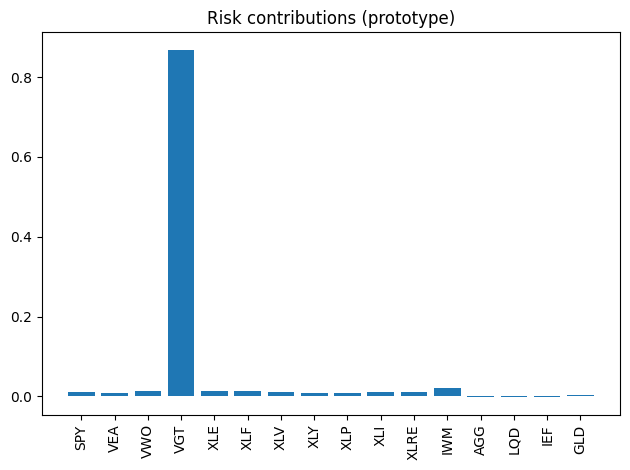

In [ ]:

def risk_contribs(w, Sigma):
    Sw = Sigma @ w
    tot = w @ Sw
    if tot <= 0:
        return np.zeros_like(w)
    return w * Sw / tot

rc = risk_contribs(proto, Sigma)
rc_df = pd.DataFrame({"ticker": tickers, "risk_contrib": rc})
display(rc_df.sort_values("risk_contrib", ascending=False))

plt.figure()
plt.bar(tickers, rc)
plt.xticks(rotation=90)
plt.title("Risk contributions (prototype)")
plt.tight_layout()
